# Official RaCo → XFeat: 蒸留実験

前半は順位・共分散 head だけを学習した旧実験（固定4枚 validation）、後半は多段・局所蒸留の新実験（固定16枚 validation と未使用144 RGB-Dペア test）を扱う。異なる評価条件の値を直接比較しない。

どちらも公開用の集計JSONだけから表示する。画像、撮影系列名、個別フレームID、学習元へのパスを含めない。旧実験の [設計・結果](../docs/raco_distillation.md)、新実験の [設計・結果](../docs/raco_multiscale.md) を参照。


## 比較する量

同じ生徒候補点 \(x\) で教師と生徒の共分散を比較する。単位は入力画像の画素の二乗。
両者の共分散へ \(0.05^2I\) を加え、Cholesky係数を補間してから \(LL^\top\) を作る。

\[
D_{T\to S}=\tfrac12\{\operatorname{tr}(\Sigma_S^{-1}\Sigma_T)-2
+\log\det\Sigma_S-\log\det\Sigma_T\}.
\]

順位は教師の生値を回帰せず、教師と生徒の候補点ペアの選好をBernoulli KLで比較する。
生徒の最終順位スコアに損失を掛ける。幾何適応では、純粋KLのbestから開始し、
既存の双方向再投影NLLを追加する。検出部と記述子は固定。

**順位utility**は、両画像の上位K点集合に残った幾何対応数をKで割り、
K={128,256,512,1024,2048,4096}で平均した値。記述子matchingの正解率とは異なる。
幾何NLLと被覆率は8画素以内で選んだ対応に条件づく。


In [1]:
from pathlib import Path
import json

root = Path.cwd()
if not (root / 'docs/raco_distillation_results.json').is_file():
    root = root.parent
result_path = root / 'docs/raco_distillation_results.json'
if not result_path.is_file():
    raise FileNotFoundError('Run from the repository root or notebooks directory')
result = json.loads(result_path.read_text())
print('protocol:', result['protocol']['evaluation'])
print('validation source frames:', result['protocol']['source_frames'])
print('seed:', result['protocol']['seed'])


protocol: fixed synthetic homographies; temporal heldout RGB frames
validation source frames: 4
seed: 20260928


In [2]:
initial = result['initial']
stages = result['stages']
teacher = result['teacher_on_student_candidates']
rows = [
    ('original student', 0, initial),
    ('rank KD', stages['ranking']['best_step'], stages['ranking']['metrics']),
    ('rank + covariance KD', stages['covariance']['best_step'], stages['covariance']['metrics']),
    ('rank + covariance adaptation', stages['adaptation']['best_step'], stages['adaptation']['metrics']),
]
print(f"{'model':30} {'best step':>9} {'rank utility ↑':>14} {'KL(T||S) ↓':>12} {'geometry NLL ↓':>16} {'coverage95':>11}")
for name, step, metrics in rows:
    print(f"{name:30} {step:9d} {metrics['rank_utility']:14.5f} "
          f"{metrics['covariance_forward_kl']:12.5f} {metrics['covariance_nll']:16.5f} "
          f"{100*metrics['student_coverage95']:10.3f}%")
print('official teacher scores on the same student candidates:')
print(f"rank utility={teacher['teacher_rank_utility']:.5f}, "
      f"geometry NLL={teacher['teacher_covariance_nll']:.5f}, "
      f"coverage95={100*teacher['teacher_coverage95']:.3f}%")


model                          best step rank utility ↑   KL(T||S) ↓   geometry NLL ↓  coverage95
original student                       0        0.32697      0.32995          3.56743     92.423%
rank KD                             6000        0.24459      0.32995          3.56743     92.423%
rank + covariance KD                5000        0.24459      0.16429          3.67144     91.396%
rank + covariance adaptation         900        0.24459      0.20615          3.57762     92.422%
official teacher scores on the same student candidates:
rank utility=0.33125, geometry NLL=3.67076, coverage95=95.224%


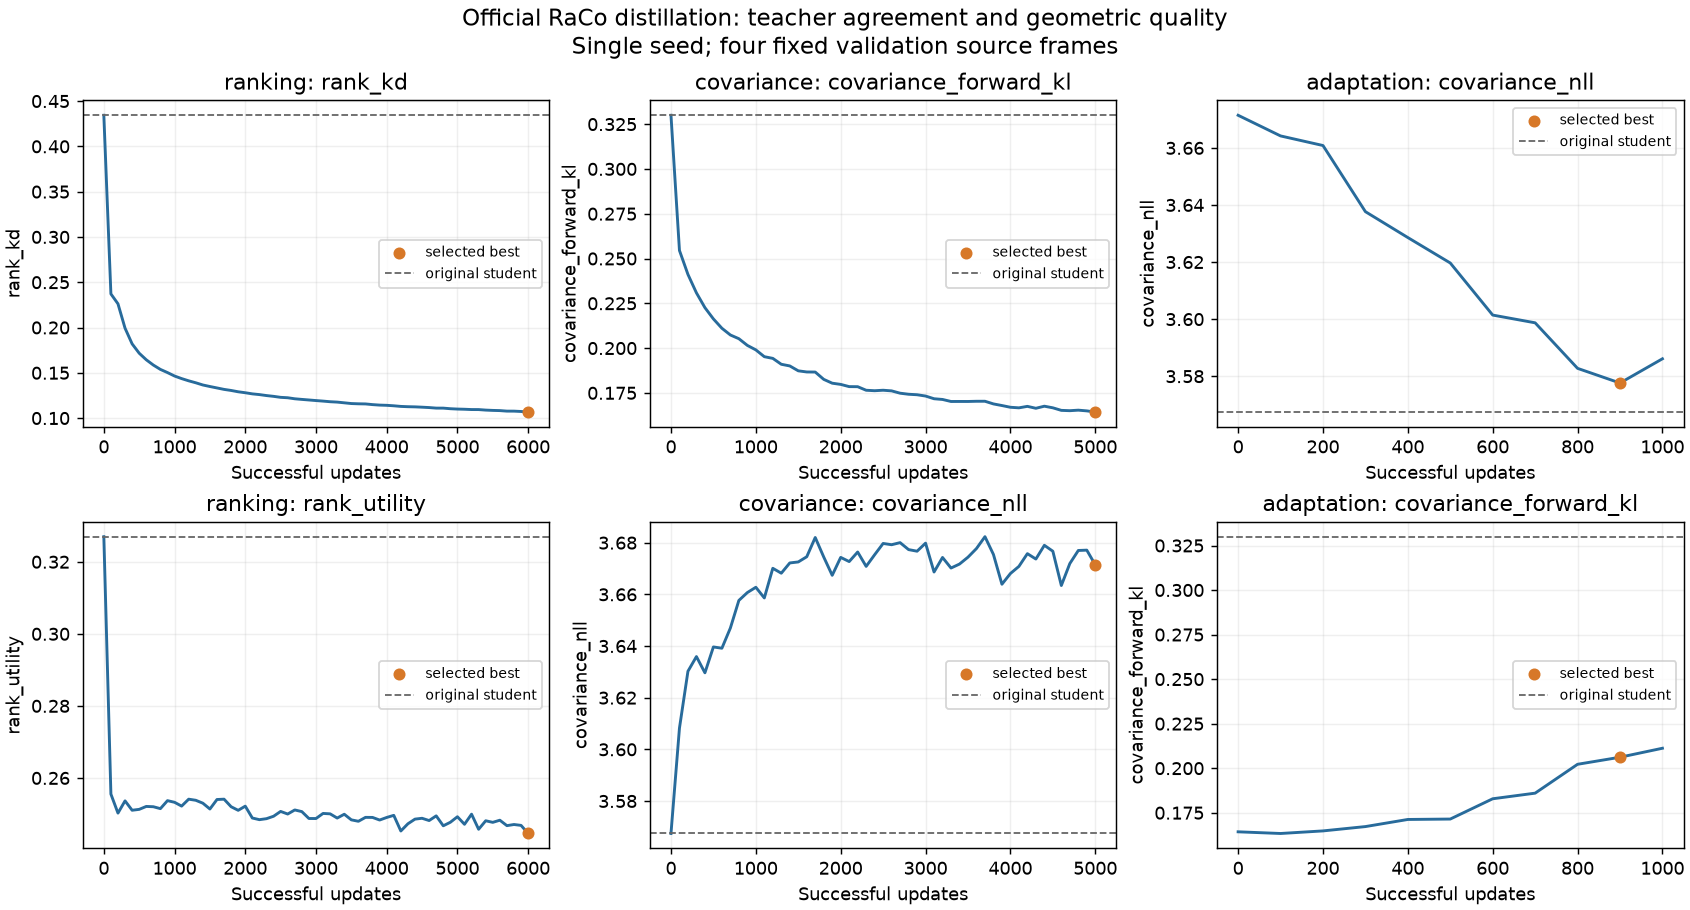

In [3]:
import matplotlib.pyplot as plt

series = [
    ('ranking', 'rank_kd', 'rank_utility'),
    ('covariance', 'covariance_forward_kl', 'covariance_nll'),
    ('adaptation', 'covariance_nll', 'covariance_forward_kl'),
]
fig, axes = plt.subplots(2, 3, figsize=(13, 7), constrained_layout=True)
for col, (name, primary, diagnostic) in enumerate(series):
    stage = stages[name]
    history = stage['validation_history']
    for row, metric in enumerate((primary, diagnostic)):
        ax = axes[row, col]
        ax.plot([point['step'] for point in history],
                [point[metric] for point in history], color='#286b9b', linewidth=1.6)
        ax.scatter([stage['best_step']], [stage['metrics'][metric]],
                   color='#d77828', s=32, zorder=4, label='selected best')
        ax.axhline(initial[metric], color='#666666', linestyle='--',
                   linewidth=1, label='original student')
        ax.set(title=f'{name}: {metric}', xlabel='Successful updates', ylabel=metric)
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8)
fig.suptitle('Official RaCo distillation: teacher agreement and geometric quality\n'
             'Single seed; four fixed validation source frames', fontsize=13)
plt.show()


## 読み取り

- 順位KDは教師との一致を改善したが、順位utilityは **0.32697→0.24459** に悪化した。
- 共分散KDは教師へのKLを **0.32995→0.16429** に下げたが、幾何NLLは **3.56743→3.67144** に悪化した。
- 幾何適応のbestはNLL **3.57762**。元の **3.56743** には届かない。
- そのため、3本の蒸留重みは比較用の実験成果物であり、元のbestを推奨する。

この停止は固定valのplateau判定で、一般的な収束を意味しない。
特に幾何適応は1000更新のramp終了時に停止した。


## 多段・局所蒸留: 固定16枚 validation と144ペア test

Aは幾何損失と記述子保持、BはAにH/8・H/32の教師特徴整合、CはAにH/8局所対比headを追加した。公式RaCoの順位出力KDは事前headroom判定を通過したため全条件で使用し、共分散出力KDは教師側の幾何NLLが劣ったため使わなかった。BCはBがAを上回らずskipし、SSKDも実行していない。学習専用headは推論bundleに含まれない。

選定指標は\(Q=\min((U-U_0)/U_0,(N_0-N)/N_0)\)。初期生徒から同じseedで各1,000成功更新し、Qが最高だったCのみ継続した。4,505更新でユーザー指示により停止し、Q最大の**3,800更新モデル**を最終形とした。validationの90%被覆率の公称値からのずれは初期生徒より悪化しており、厳格な採用条件に対する**明示的な例外**である。testでは再選定しない。


In [ ]:
from pathlib import Path
import json

root = Path.cwd()
if not (root / 'docs/raco_multiscale_results.json').is_file():
    root = root.parent
multiscale = json.loads((root / 'docs/raco_multiscale_results.json').read_text())
sel = multiscale['selection']
val = multiscale['validation']
test = multiscale['test']
print('selected:', sel['selected_variant'], 'step', sel['selected_step'], 'Q', f"{sel['selected_q']:.6f}")
print('first 1000 best Q:', {k: round(v['best_q'], 6) for k, v in val['first_1000'].items()})
print(f"{'split / model':24} {'utility ↑':>10} {'TP@512 ↑':>10} {'NLL ↓':>10} {'cov50':>9} {'cov90':>9} {'cov95':>9}")
for split_name, records in [('val', val), ('test', test)]:
    for name in ('baseline', 'selected'):
        row = records[name]
        print(f"{split_name+' / '+name:24} {row['rank_utility' if split_name=='val' else 'mean_rank_utility']:10.6f} "
              f"{row['descriptor_tp512' if split_name=='val' else 'descriptor_TP512']:10d} "
              f"{row['covariance_nll' if split_name=='val' else 'mean_nll']:10.6f} "
              f"{row['coverage50']:9.6f} {row['coverage90']:9.6f} {row['coverage95']:9.6f}")
print('val 90% nominal deviation:', val['coverage90_nominal_deviation'])


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
colors = {'A': '#3b7fbb', 'B': '#d08c2f', 'C': '#348a60'}
for variant, history in val['curves'].items():
    axes[0].plot([row['step'] for row in history], [row['q'] for row in history],
                 marker='.', markersize=3, label=variant, color=colors[variant])
axes[0].scatter([sel['selected_step']], [sel['selected_q']], s=65,
                color='#c93b40', zorder=5, label='selected 3800')
axes[0].axhline(0, color='#777', linewidth=0.8)
axes[0].set(xlabel='Successful updates', ylabel='Validation Q',
            title='Fixed 16-frame synthetic validation')
axes[0].legend(); axes[0].grid(alpha=0.2)
labels = ['rank utility', 'TP@512', 'NLL', 'coverage90']
b = test['baseline']; s = test['selected']
relative = [(s['mean_rank_utility']/b['mean_rank_utility']-1)*100,
            (s['descriptor_TP512']/b['descriptor_TP512']-1)*100,
            (s['mean_nll']/b['mean_nll']-1)*100,
            (s['coverage90']/b['coverage90']-1)*100]
axes[1].bar(labels, relative, color=['#348a60','#348a60','#c93b40','#c93b40'])
axes[1].axhline(0, color='#777', linewidth=0.8)
axes[1].set(ylabel='Relative change vs initial student (%)',
            title='Locked 144-pair RGB-D test; lower NLL is better')
axes[1].tick_params(axis='x', rotation=20)
plt.show()


### 解釈と制約

固定validationでは3,800更新の順位utility・TP@512・NLLが改善した。ただし90%被覆率の公称値からのずれは **0.002207→0.006571** へ悪化した。実RGB-D testでは順位utility **0.050836→0.060593** とTP@512 **3,129→3,581** が改善した一方、NLL **3.597599→3.718465**、50/90/95%被覆率はすべて悪化した。共分散を校正済みとして利用する用途には、追加の調整と独立した検証が必要である。

Validationは合成homographyの疑似対応、testは深度可視性を確認した実ペアの相互幾何対応を使う。testの8×8位相別幾何残差は両モデルで浮動小数点丸め誤差以内に同じで、位置精度の改善を示さない。test144ペアは同じ二系列から成り、フレームがペア間で再利用される。未知シーンへの汎化、無条件の不確実性校正、共分散を使った姿勢推定精度は未検証である。
